## SARIMA Model - Time Series Analysis (Series 3)
### Objective
This notebook analyzes the time series of Pneumonia cases (15+ years, BCN Nord) using the Box-Jenkins methodology, including model fitting, validation and forecasting, using weekly data in period: 2012-2024

### Methodology
1. Exploratory analysis
2. Stationarity analysis
3. Model identification
4. Model estimation
5. Validation
6. Forecasting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
import skforecast
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme, plot_prediction_intervals
from skforecast.stats import Sarimax, Arima
from skforecast.recursive import ForecasterStats
from skforecast.utils import expand_index
from skforecast.model_selection import TimeSeriesFold, backtesting_stats, grid_search_stats

warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings("ignore")


COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

### Data Filtering

Is it selected the subset corresponding to:
- Diagnosis: Pneumonia
- Region: Barcelona Metropolitana Nord
- Age group: 15+

In [2]:
df_serie = df[
    (df["diagnostic"] == "PneumÃ²nia") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "15+")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

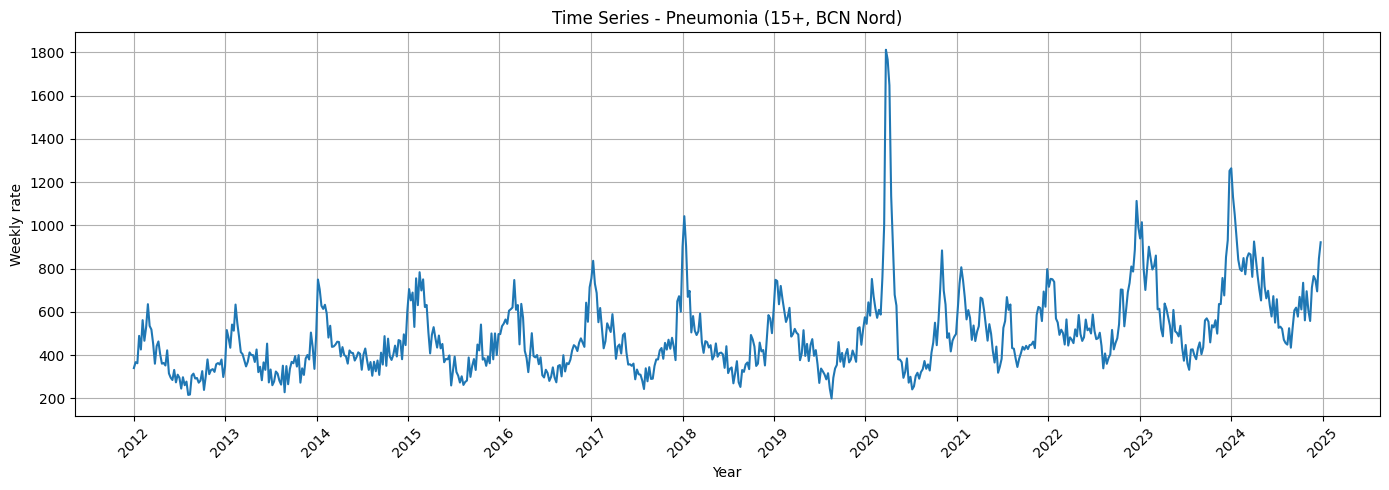

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Time Series - Pneumonia (15+, BCN Nord)")
plt.ylabel("Weekly rate")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Train-Test Split

The dataset is split into:
- Training set: used for model estimation (2012-2019)
- Test set: used for validation and forecasting performance (2020-2024)

In [4]:
serie_3 = serie.copy()

train = serie_3[serie_3.index < "2020-01-01"]
test  = serie_3[serie_3.index >= "2020-01-01"]

#Missing weekly values are linearly interpolated to preserve regular frequency before modeling.
train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


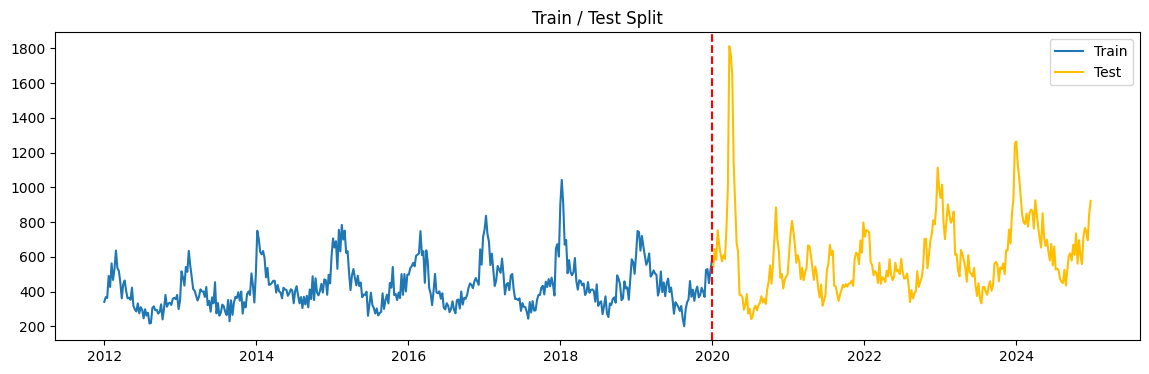

In [5]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Train / Test Split")
plt.show()

## Exploratory Analysis

The original time series shows:

- a clear seasonal pattern,
- changes in variability over time,
- and a possible smooth trend component.

Since the variability appears to increase with the level of the series, a variance-stabilizing transformation is considered before modeling.

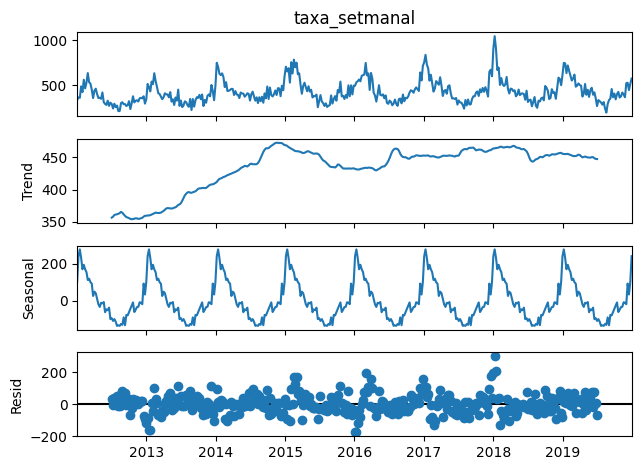

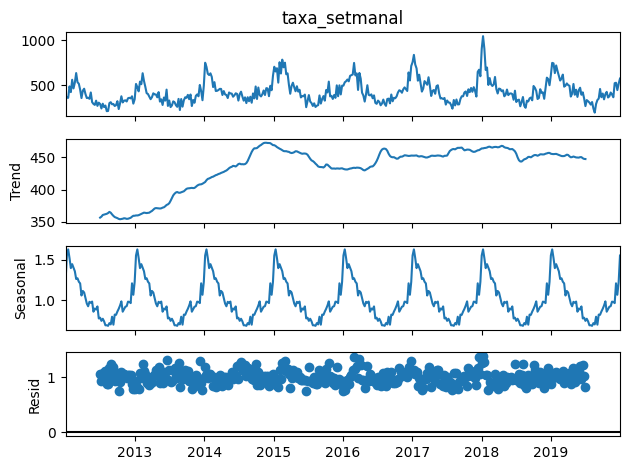

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

decomp_mult = seasonal_decompose(train, model="multiplicative", period=52)
decomp_mult.plot()
plt.show()

In [7]:
print("Global mean (train):", train.mean())
print("Global variance (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\n Mean per year:")
print(yearly_mean)

print("\nVariance per year:")
print(yearly_var)

Global mean (train): 429.12393552200444
Global variance (train): 15736.346409409314

 Mean per year:
date
2012-12-31    356.493275
2013-12-31    380.345383
2014-12-31    440.240085
2015-12-31    452.511393
2016-12-31    446.004588
2017-12-31    450.860032
2018-12-31    460.780088
2019-12-31    446.544613
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variance per year:
date
2012-12-31     8141.644983
2013-12-31     7281.025019
2014-12-31     9465.983945
2015-12-31    19708.249724
2016-12-31    14856.033179
2017-12-31    17807.082087
2018-12-31    24364.637055
2019-12-31    15690.858019
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


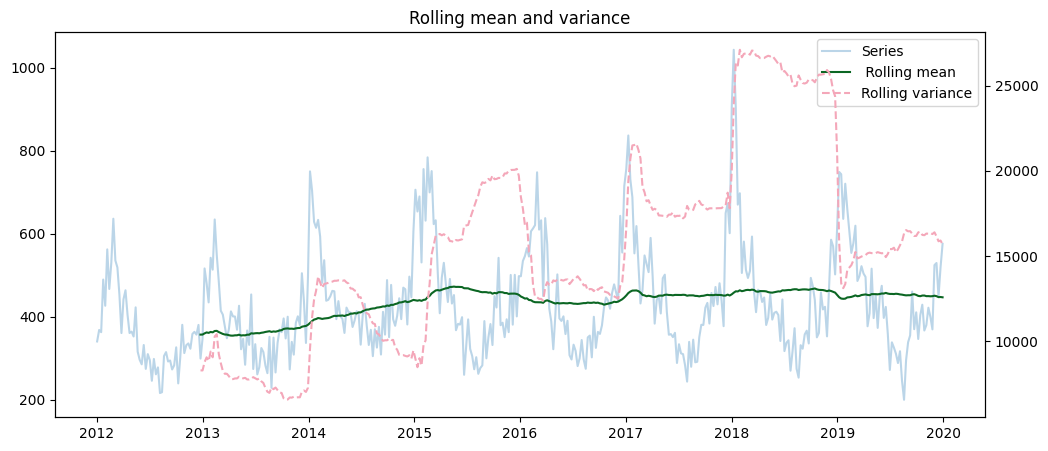

In [8]:
rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Series')
l2, = ax1.plot(rolling_mean, label=' Rolling mean', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Rolling variance', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Rolling mean and variance")
plt.show()

### Log Transformation

Because the variance is not stable in the original scale, a logarithmic transformation is applied.

After transformation, the series shows a more homogeneous variability over time. Therefore, the analysis and subsequent SARIMA modeling are carried out on the log-transformed series.

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


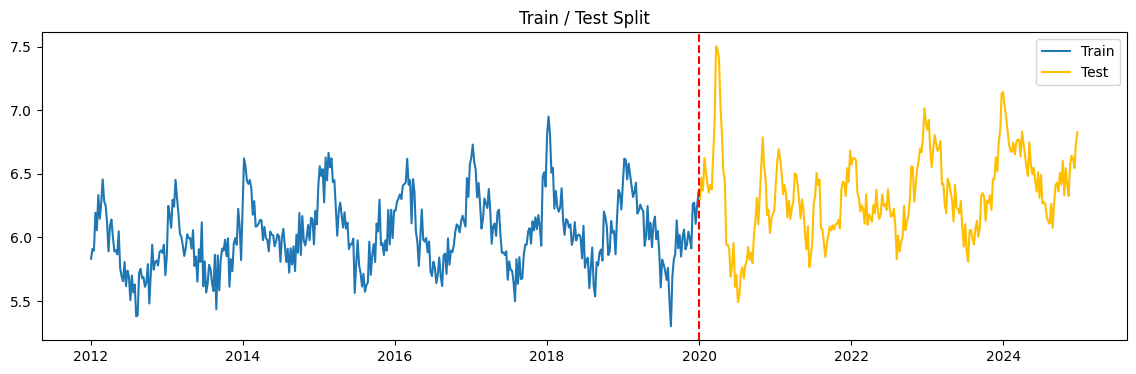

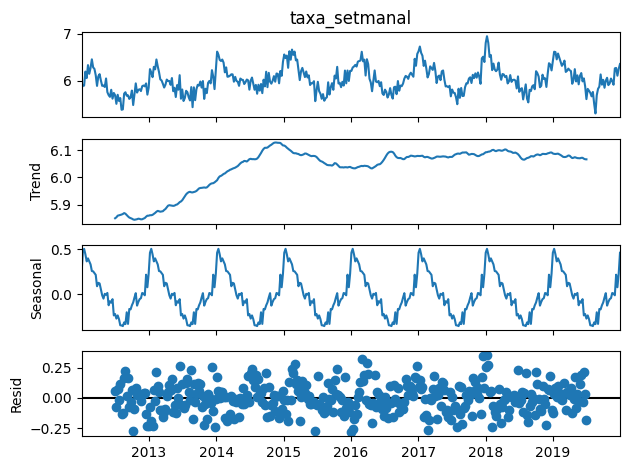

Global mean (train_log): 6.025698138775522
Global variance (train_log): 0.07445753390920708

 Mean per year:
date
2012-12-31    5.850479
2013-12-31    5.919982
2014-12-31    6.068587
2015-12-31    6.072791
2016-12-31    6.067451
2017-12-31    6.073352
2018-12-31    6.089585
2019-12-31    6.065499
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variance per year:
date
2012-12-31    0.056472
2013-12-31    0.047995
2014-12-31    0.040504
2015-12-31    0.088282
2016-12-31    0.070663
2017-12-31    0.079923
2018-12-31    0.085568
2019-12-31    0.079221
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


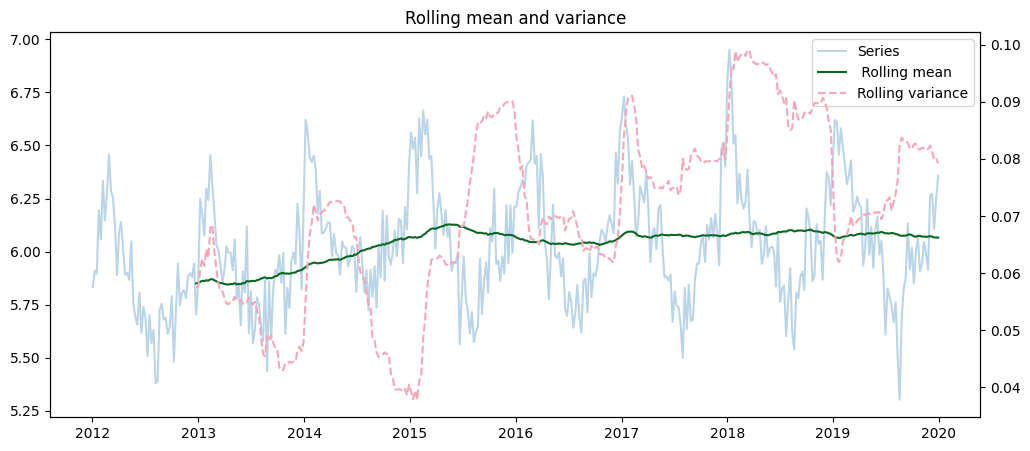

In [9]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print(train_log.index.min(), train_log.index.max())
print(test_log.index.min(), test_log.index.max())

plt.figure(figsize=(14,4))

plt.plot(train_log, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test_log, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train_log.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Train / Test Split")
plt.show()

decomp_log = seasonal_decompose(train_log, model="additive", period=52)
decomp_log.plot()
plt.show()

print("Global mean (train_log):", train_log.mean())
print("Global variance (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\n Mean per year:")
print(yearly_mean)

print("\nVariance per year:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Series')
l2, = ax1.plot(rolling_meanlog, label=' Rolling mean', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Rolling variance', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Rolling mean and variance")
plt.show()

### Original ACF

After the decomposition, the ACF of the original series is examined to assess the possible presence of seasonality.

Significant peaks at seasonal lags, particularly around (m = 52), suggest a clear annual seasonal pattern. This provides an initial indication that seasonal differencing may be needed.

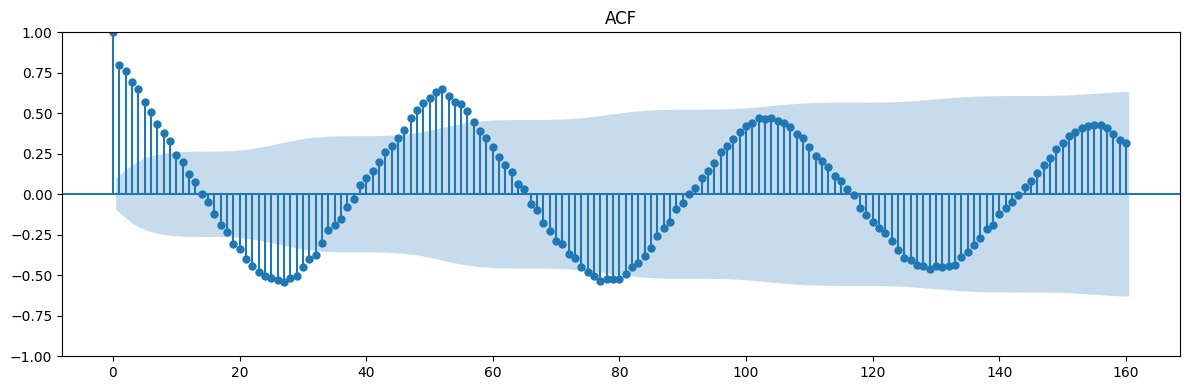

In [10]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF")
plt.tight_layout()
plt.show()

### Stationarity Analysis

To assess stationarity, two statistical tests are applied to the log-transformed training series:

- Augmented Dickey-Fuller (ADF)
- KPSS test

### Interpretation

- ADF: H0 = non-stationary
- KPSS: H0 = stationary

Results:

- ADF rejects the null of non-stationarity
- KPSS does not reject the null of stationarity

Taken together, these results suggest that the log-transformed series may be stationary.

In [11]:
dftest = adfuller(train_log, autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("P-Value : ", dftest[1])

stat, p_value, lags, crit = kpss(train_log, regression='c', nlags='auto')

print("\n2. KPSS :", stat)
print("P-value:", p_value)

1. ADF :  -6.156348078417716
P-Value :  7.352719898308831e-08

2. KPSS : 0.24986934478183243
P-value: 0.1


## Descriptive Analysis

To complement the statistical tests, the rolling mean and rolling variance were examined on the log-transformed series.

The rolling mean appears reasonably stable over time, while the rolling variance is notably more homogeneous after the logarithmic transformation.

This supports the idea that the log transformation improves the stability of the series and makes it more suitable for modeling.

### Seasonal Differencing Check

To further assess whether seasonal differencing is appropriate, the series after applying one seasonal difference, is compared with the original series, and the ACF is examined again.

After applying seasonal differencing, the annual repeating pattern is substantially attenuated, and the seasonal peaks in the ACF become notably weaker. This supports the choice of seasonal differencing of order one, D = 1.

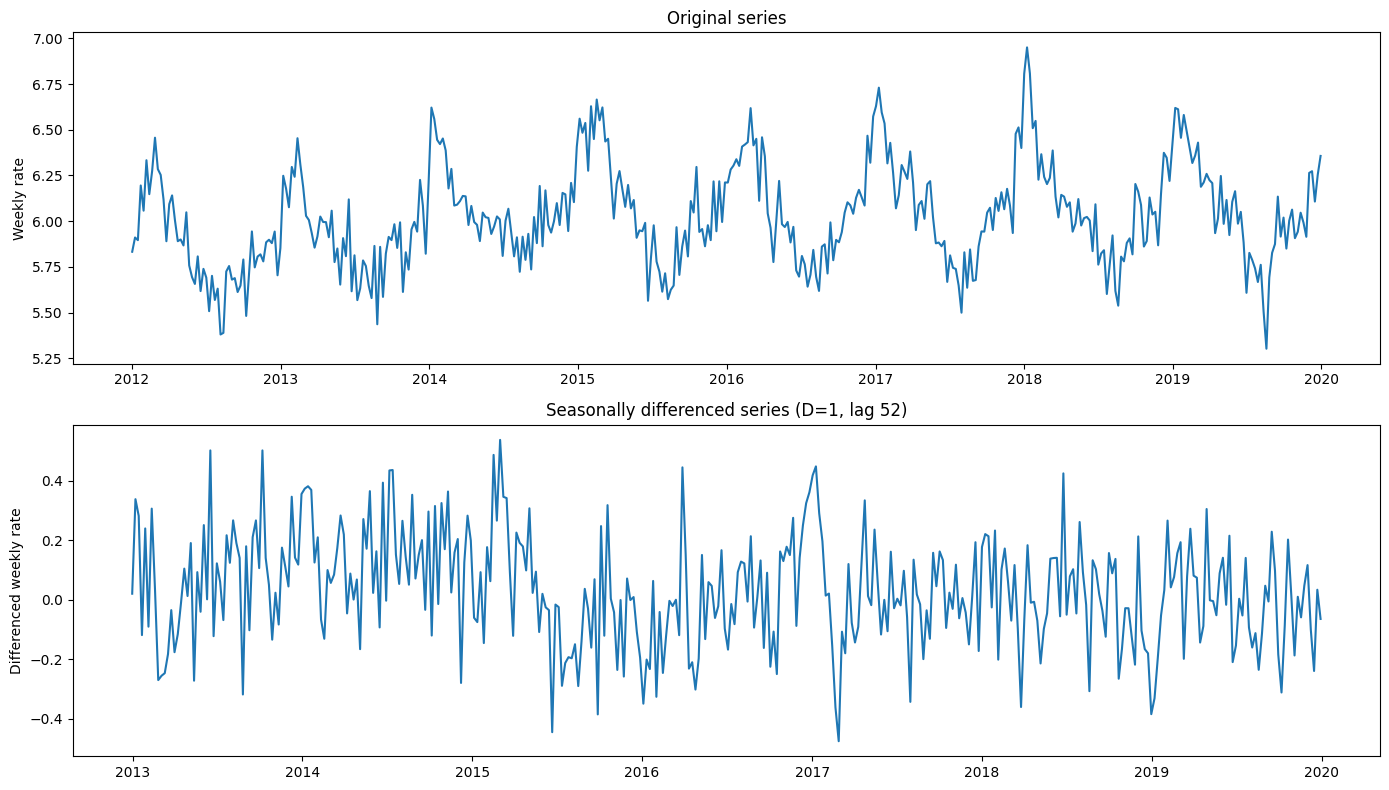

In [12]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Original series")
axes[0].set_ylabel("Weekly rate")

axes[1].plot(serie_D1)
axes[1].set_title("Seasonally differenced series (D=1, lag 52)")
axes[1].set_ylabel("Differenced weekly rate")

plt.tight_layout()
plt.show()

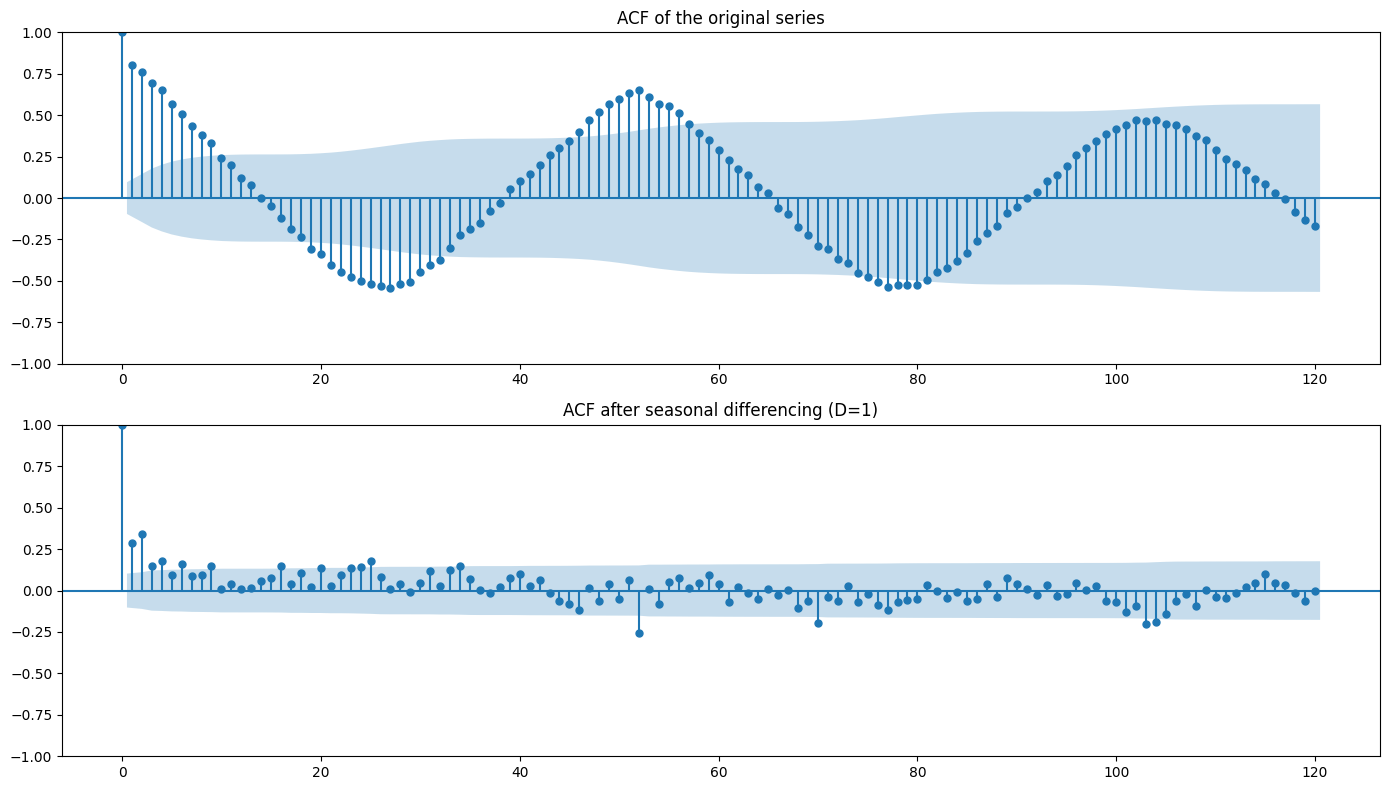

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF of the original series")

plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF after seasonal differencing (D=1)")

plt.tight_layout()
plt.show()

### Differencing Selection

The logarithmic transformation was retained because it improves the stability of the variance, while the rolling mean remains reasonably stable over time.

Regarding the mean structure, the formal stationarity tests are consistent: the ADF test rejects the null of non-stationarity, and the KPSS test does not reject the null of stationarity. Therefore, no additional regular differencing is considered necessary.

To assess seasonality, the series after one seasonal difference is compared with the original series and the ACF is examined again. After applying seasonal differencing, the annual repeating pattern is substantially attenuated and the seasonal peaks in the ACF become notably weaker. This supports the choice of seasonal differencing of order one.

Therefore, the final specification adopts:
- non-seasonal differencing: d = 0
- seasonal differencing: D = 1

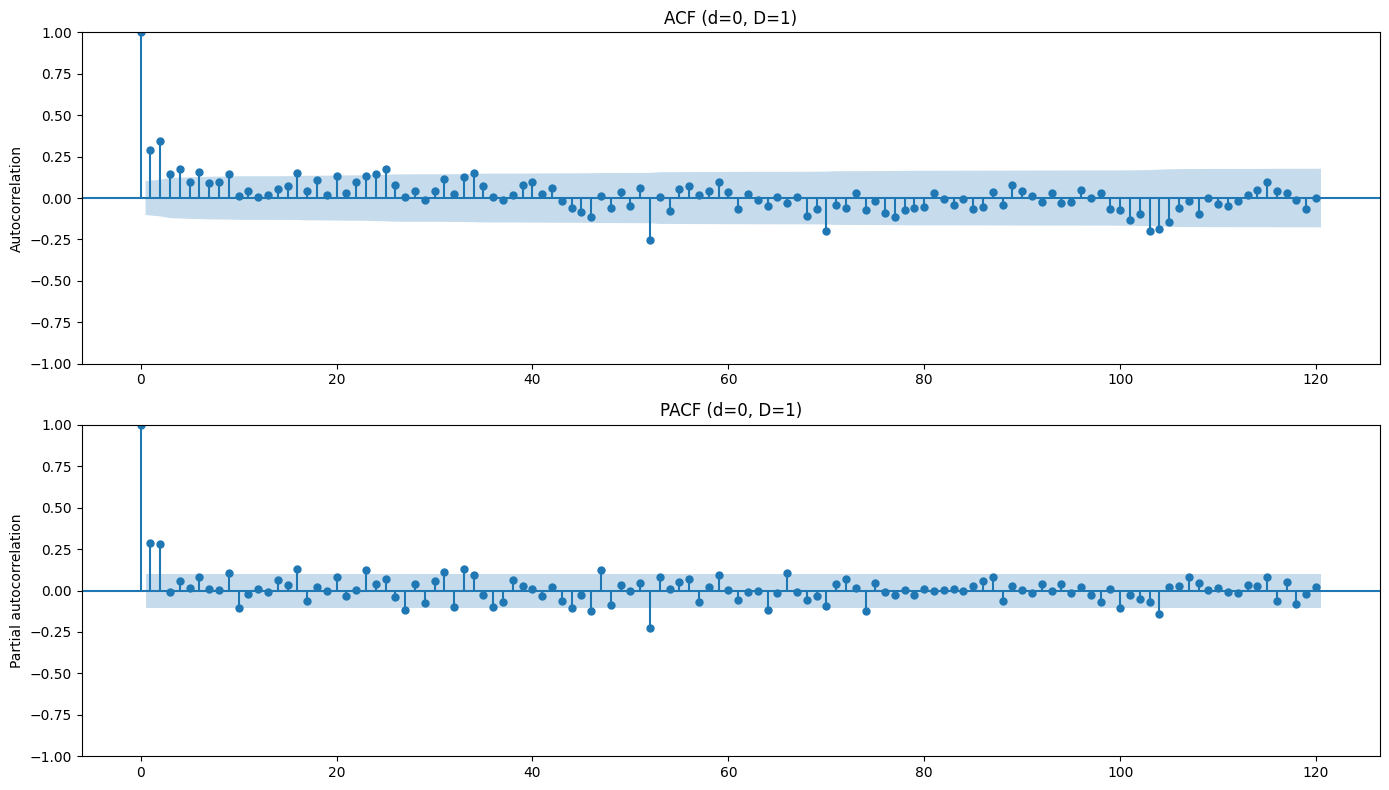

In [14]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_D1, lags=120, ax=axes[0])
axes[0].set_title("ACF (d=0, D=1)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("PACF (d=0, D=1)")
axes[1].set_ylabel("Partial autocorrelation")

plt.tight_layout()
plt.show()

### ACF and PACF Analysis

The ACF and PACF of the transformed series are examined to guide model specification.

Observations:

- The ACF shows a gradual decay with a clear seasonal spike at lag 52.
- The PACF suggests a short-term autoregressive structure.

This behavior supports the inclusion of both AR and MA components, as well as a seasonal MA term.

## Model Selection

I test several SARIMA models based on ACF/PACF insights and compare them using AIC.

Each model is fitted using the training data.

In [15]:
models = [
    ((1,0,1), (0,1,1,52)),
    ((1,0,0), (0,1,1,52)),
    ((2,0,0), (0,1,1,52)),
    ((2,0,1), (0,1,1,52)),
    ((1,0,0), (1,1,1,52)),
    ((1,0,1), (0,1,0,52)),
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA{order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA{order}{seasonal_order}")


print("\n Best model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA(1, 0, 1)(0, 1, 1, 52)
AIC: -311.25460568727954
----------------------------------------
Model SARIMA(1, 0, 0)(0, 1, 1, 52)
AIC: -280.01200501212685
----------------------------------------
Model SARIMA(2, 0, 0)(0, 1, 1, 52)
AIC: -301.6787289311345
----------------------------------------
Model SARIMA(2, 0, 1)(0, 1, 1, 52)
AIC: -311.034511469477
----------------------------------------
Model SARIMA(1, 0, 0)(1, 1, 1, 52)
AIC: -258.21102239770164
----------------------------------------
Model SARIMA(1, 0, 1)(0, 1, 0, 52)
AIC: -238.7209455968917
----------------------------------------

 Best model:
((1, 0, 1), (0, 1, 1, 52))
AIC: -311.25460568727954


In [16]:
model1 = SARIMAX(train_log,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 52)   Log Likelihood                 159.627
Date:                            Sat, 11 Apr 2026   AIC                           -311.255
Time:                                    18:33:10   BIC                           -296.283
Sample:                                01-02-2012   HQIC                          -305.271
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8747      0.038     23.293      0.000       0.801       0.948
ma.L1         -0.5897      0.071   

In [17]:
model2 = SARIMAX(train_log,
                order=(2,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2= model2.fit()
print(result2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 1)x(0, 1, 1, 52)   Log Likelihood                 160.517
Date:                            Sat, 11 Apr 2026   AIC                           -311.035
Time:                                    18:33:23   BIC                           -292.319
Sample:                                01-02-2012   HQIC                          -303.555
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2690      0.067     19.000      0.000       1.138       1.400
ar.L2         -0.2805      0.063   

## Model Selection for Residual Validation

After this first comparison, only two models are retained for further analysis, since they provide the best balance between:

- low AIC values,
- significant parameters,
- and stable estimation.

These two models are selected as the strongest candidates for residual diagnostics and forecasting evaluation.

To perform a more rigorous residual assessment, the diagnostic analysis was conducted after excluding the initial burn-in period of each fitted model. This step is justified by the state-space representation used in SARIMA estimation, where the first residuals may be affected by filter initialization and therefore may not be fully representative of the stable residual behavior of the model. For this reason, residual diagnostics were based only on the post–burn-in residuals.

Burn-in used: 106


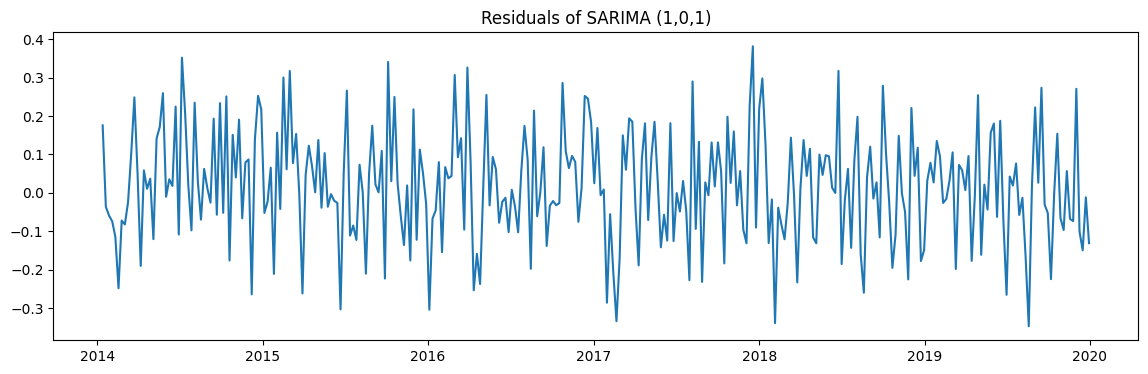

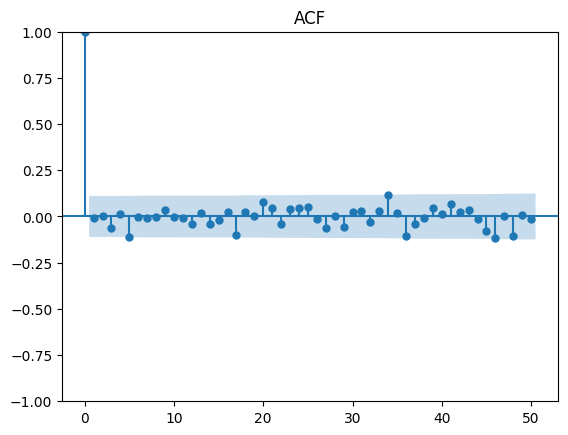


 Ljung Box
      lb_stat  lb_pvalue
10   5.779721   0.833418
20  13.005457   0.877150
30  19.222250   0.935232

Mean of residuals: 0.017299318632341267
Std of residuals: 0.14429543667968955
Relative mean (|mean| / std): 0.11988818933160518


In [18]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual1)
plt.title("Residuals of SARIMA (1,0,1)")
plt.show()

plot_acf(residual1, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual1, lags=[10, 20, 30], return_df=True))

mean_resid = residual1.mean()
std_resid = residual1.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 106


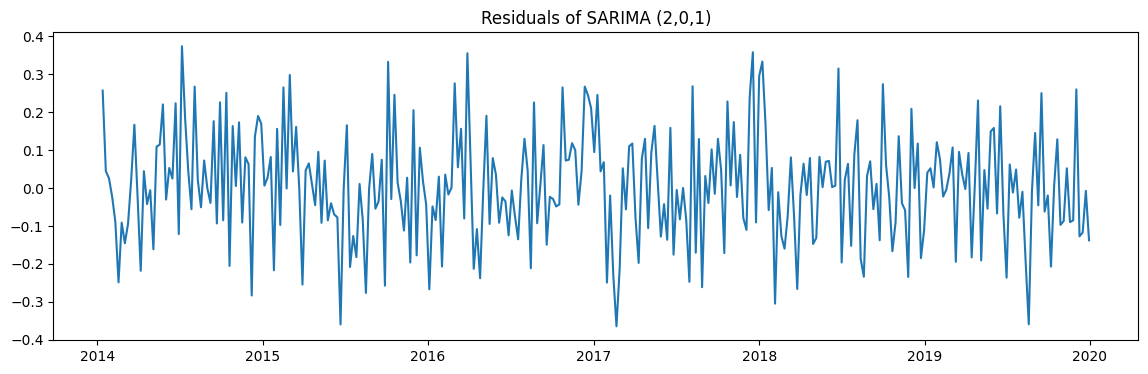

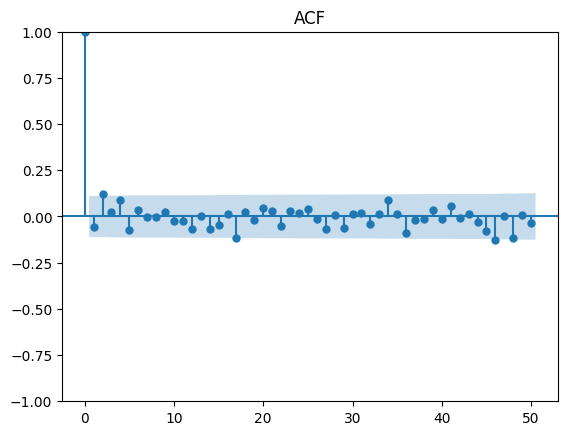


Ljung-Box
      lb_stat  lb_pvalue
10  11.062562   0.352665
20  20.563954   0.423185
30  25.667035   0.692012

Mean of residuals: 0.003274951791014711
Std of residuals: 0.1448763752394512
Relative mean (|mean| / std): 0.022605147220186046


In [19]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual2)
plt.title("Residuals of SARIMA (2,0,1)")
plt.show()

plot_acf(residual2, lags=50)
plt.title("ACF")
plt.show()

print("\nLjung-Box")
print(acorr_ljungbox(residual2, lags=[10, 20, 30], return_df=True))

mean_resid = residual2.mean()
std_resid = residual2.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

### Residual Validation Results

Residuals are analyzed to assess model adequacy.

For both candidate models, residuals remain centered around zero and their overall behaviour is compatible with an approximately white-noise process. The residual autocorrelation is generally low, and the diagnostic checks do not reveal major misspecification problems.

Although both models provide acceptable residual diagnostics, the SARIMA(1,0,1)(0,1,1,52) specification shows slightly more favorable results overall, particularly in terms of the Ljung–Box statistics and the general residual structure. Therefore, from the point of view of residual validation, it provides a somewhat cleaner specification.

In [20]:
# Model 1
pred1 = result1.get_forecast(steps=len(test_log))
pred1_mean = pred1.predicted_mean

mae1 = mean_absolute_error(test_log, pred1_mean)
rmse1 = root_mean_squared_error(test_log, pred1_mean)


# Model 2
pred2 = result2.get_forecast(steps=len(test_log))
pred2_mean = pred2.predicted_mean

mae2 = mean_absolute_error(test_log, pred2_mean)
rmse2 = root_mean_squared_error(test_log, pred2_mean)


print("Model (1,0,1) → MAE:", mae1, "RMSE:", rmse1)
print("Model (2,0,1) → MAE:", mae2, "RMSE:", rmse2)

Model (1,0,1) → MAE: 0.31742932219399184 RMSE: 0.39066134524079243
Model (2,0,1) → MAE: 0.31561843801944817 RMSE: 0.38884496490529485


### Final Model Selection

Both candidate models show very similar forecasting performance.

Although the SARIMA(2,0,1)(0,1,1,52) model achieves slightly lower MAE and RMSE values, the improvement is only marginal. In contrast, the SARIMA(1,0,1)(0,1,1,52) model combines a lower AIC, slightly more favorable residual diagnostics, and a more parsimonious structure.

Therefore, the SARIMA(1,0,1)(0,1,1,52) model is selected as the final model, since it provides the best overall balance between goodness of fit, residual behaviour, predictive performance, and model simplicity.

### Forecasting
Once the model has been validated, I generate forecasts using the test set horizon.

The objective is to evaluate how well the model captures:
- the overall trend
- the seasonal pattern
- the variability of the series

Predictions are accompanied by prediction intervals, which reflect the uncertainty of the model.

In [21]:
#Final model
model = SARIMAX(train_log,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log)

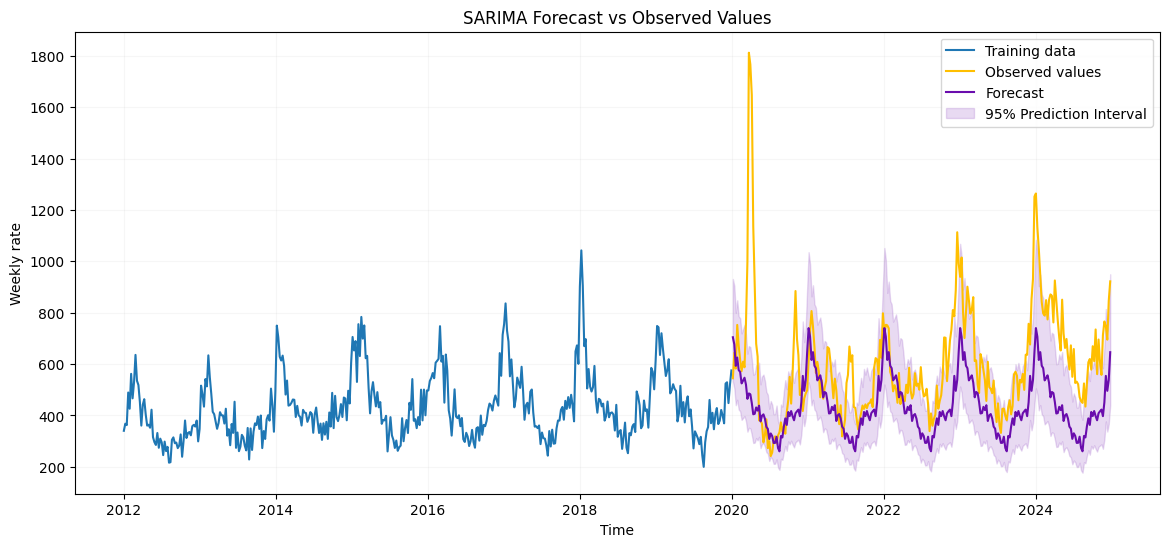

In [22]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Training data', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction Interval')

plt.legend()
plt.title("SARIMA Forecast vs Observed Values")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)
plt.show()

In [23]:
mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)

covTotal = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

print("TOTAL")
print("MAE:", mae_total)
print("RMSE:", rmse_total)
print("Coverage:", covTotal)

TOTAL
MAE: 175.30781222006593
RMSE: 247.25255757494898
Coverage: 0.6038461538461538


### Forecast Evaluation

To quantitatively evaluate the forecasting performance, I compute error metrics such as:

Mean Absolute Error (MAE)
Root Mean Squared Error (RMSE)
These metrics measure the difference between observed and predicted values, allowing me to assess the accuracy of the model.

The empirical coverage of the 95% prediction intervals is about 0.6, which is below the nominal level and suggests that forecast uncertainty is underestimated.

To further investigate this issue, the test period is divided into two subperiods:

COVID period
Post-COVID period
This allows me to analyze whether the model behaves differently under structural changes in the data


In [24]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

 
mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)

cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

print("\nCOVID (2020-2021)")
print("MAE:", mae_covid)
print("RMSE:", rmse_covid)
print("Coverage:", cov_covid)


mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)


cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

print("\nPOST-COVID (2022-2024)")
print("MAE:", mae_post)
print("RMSE:", rmse_post)
print("Coverage:", cov_post)


COVID (2020-2021)
MAE: 147.0794792538757
RMSE: 272.9121960407582
Coverage: 0.75

POST-COVID (2022-2024)
MAE: 194.12670086419277
RMSE: 228.5512361529969
Coverage: 0.5064102564102564


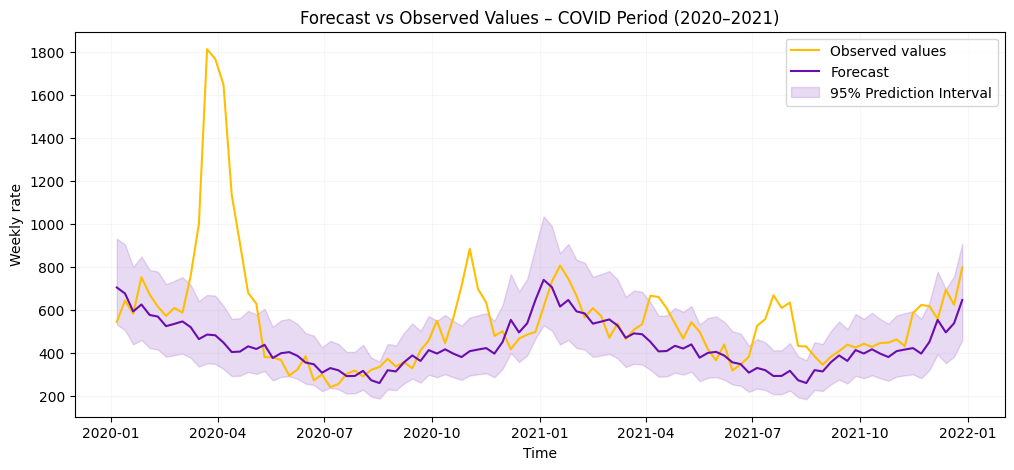

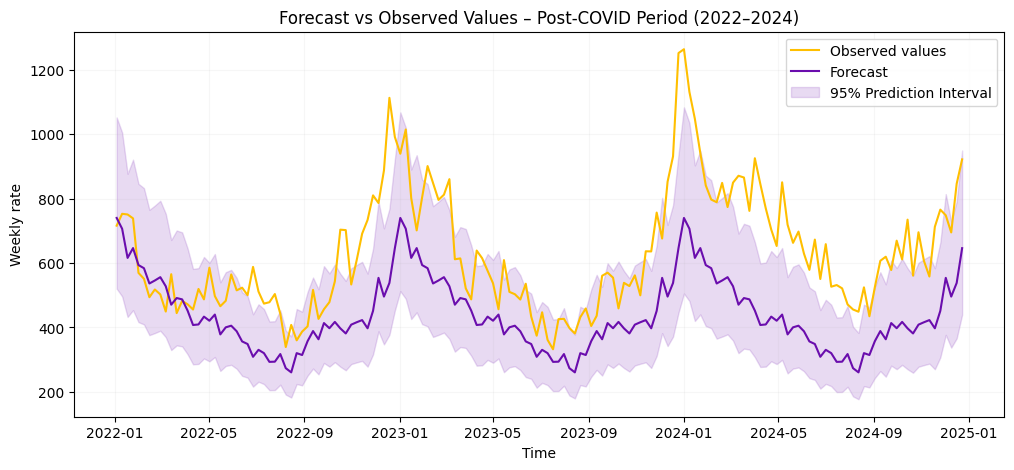

In [25]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction Interval')

plt.title("Forecast vs Observed Values – COVID Period (2020–2021)")
plt.xlabel("Time")
plt.ylabel("Weekly rate") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction Interval')

plt.title("Forecast vs Observed Values – Post-COVID Period (2022–2024)")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

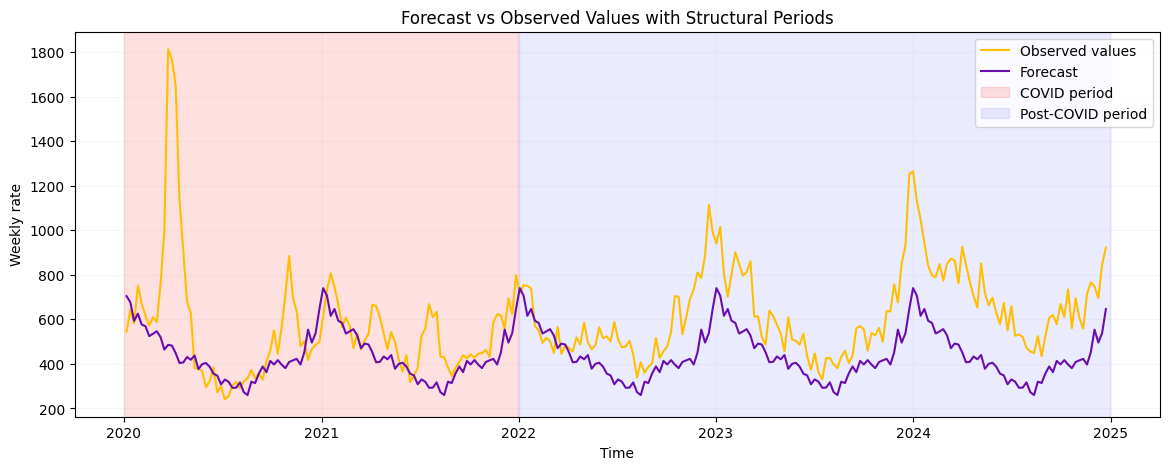

In [26]:
plt.figure(figsize=(14,5))

plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.axvspan(pd.to_datetime("2020-01-01"),
            pd.to_datetime("2021-12-31"),
            color='red', alpha=0.12, label='COVID period')

plt.axvspan(pd.to_datetime("2022-01-01"),
            pd.to_datetime("2024-12-31"),
            color='blue', alpha=0.08, label='Post-COVID period')

plt.legend()
plt.title("Forecast vs Observed Values with Structural Periods")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)

plt.show()

### Visual Analysis (Pneumonia)

The pneumonia series exhibits a different behavior compared to other diagnoses, both visually and in terms of forecast metrics.

During the COVID period (2020–2021), the model shows a relatively good coverage (~0.76), meaning that a large proportion of observed values fall within the predicted confidence intervals. However, error metrics such as RMSE are higher, indicating that when the model misses, it does so with larger deviations.

This suggests that the model captures the overall uncertainty during this period but struggles to accurately estimate the magnitude of the changes. A plausible explanation is the shift in diagnostic practices, where many respiratory cases were classified as COVID-19 instead of pneumonia, altering the data-generating process in a more systematic way.

In contrast, during the post-COVID period (2022–2024), the model achieves lower RMSE, indicating better point predictions. However, coverage drops significantly (~0.52), suggesting that prediction intervals are not well calibrated and fail to capture the true variability of the series.

Visually, this is consistent with the model tracking the general level of the series more closely, while underestimating variability and missing peaks more frequently.

Overall, this behavior highlights a trade-off between point accuracy and uncertainty estimation, and reinforces the idea that model performance must be interpreted beyond a single metric.